In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/diwali_sales_data.csv")

In [3]:
df.head()

,Order_ID,User_ID,Cust_name,Gender,Age,Age_Group,Marital_Status,State,Occupation,Product_Category,Product,Price,Quantity,Discount,Purchase,Amount,Order_Date,Platform,Payment_Method
0,ORD10362,1096,Pooja,F,45.0,36-45,0,Gujarat,Marketing,Footwear,Formal Shoes,592.42,4,0.10,2369.68,2132.71,2025-10-17,Myntra,Cash
1,ORD10074,1158,Vikash,F,23.0,18-25,1,Karnataka,Teacher,Grocery,Oil,1621.61,5,0.20,8108.05,6486.44,2025-11-05,Amazon,Net Banking
2,ORD10375,1021,Rahul,F,59.0,56-60,0,Bihar,Engineering,Clothing,Jeans,4315.93,4,0.05,17263.72,16400.53,2025-10-04,Flipkart,Cash
3,ORD10156,1047,Priya,F,45.0,36-45,0,Uttar Pradesh,IT,Electronics,Smartphone,26607.14,2,0.10,53214.28,47892.85,2025-10-21,Flipkart,UPI
4,ORD10105,1132,Rohan,M,55.0,46-55,1,Madhya Pradesh,Government,Books,Programming Book,828.41,3,0.20,2485.23,1988.18,2025-11-14,Myntra,Debit Card


In [4]:
df.tail()

,Order_ID,User_ID,Cust_name,Gender,Age,Age_Group,Marital_Status,State,Occupation,Product_Category,Product,Price,Quantity,Discount,Purchase,Amount,Order_Date,Platform,Payment_Method
495,ORD10107,1172,Rohan,M,52.0,46-55,1,Tamil Nadu,Healthcare,Food,Chocolates,1690.65,1,0.10,1690.65,1521.58,2025-10-07,Meesho,Credit Card
496,ORD10271,1179,Kavya,M,36.0,36-45,0,Uttar Pradesh,IT,Grocery,Rice,2012.04,3,0.20,6036.12,4828.90,2025-10-28,Amazon,UPI
497,ORD10349,1089,Vivaan,M,18.0,18-25,0,Madhya Pradesh,Business,Food,Sweets,2697.13,4,0.10,10788.52,9709.67,2025-10-22,Myntra,Cash
498,ORD10436,1075,Simran,F,35.0,26-35,0,Delhi,Marketing,Footwear,Slippers,1765.00,3,0.10,5295.00,4765.50,2025-10-08,Myntra,UPI
499,ORD10103,1001,Shreya,F,50.0,46-55,1,Karnataka,Engineering,Food,Dry Fruits,188.12,1,0.15,188.12,159.90,2025-10-20,Amazon,Credit Card


In [5]:
df.shape

(500, 19)

In [6]:
df.columns

Index(['Order_ID', 'User_ID', 'Cust_name', 'Gender', 'Age', 'Age_Group',
       'Marital_Status', 'State', 'Occupation', 'Product_Category', 'Product',
       'Price', 'Quantity', 'Discount', 'Purchase', 'Amount', 'Order_Date',
       'Platform', 'Payment_Method'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          500 non-null    object 
 1   User_ID           500 non-null    int64  
 2   Cust_name         500 non-null    object 
 3   Gender            500 non-null    object 
 4   Age               497 non-null    float64
 5   Age_Group         500 non-null    object 
 6   Marital_Status    500 non-null    int64  
 7   State             498 non-null    object 
 8   Occupation        497 non-null    object 
 9   Product_Category  498 non-null    object 
 10  Product           500 non-null    object 
 11  Price             500 non-null    float64
 12  Quantity          500 non-null    int64  
 13  Discount          500 non-null    float64
 14  Purchase          500 non-null    float64
 15  Amount            498 non-null    float64
 16  Order_Date        500 non-null    object 
 1

In [8]:
df.describe()

,User_ID,Age,Marital_Status,Price,Quantity,Discount,Purchase,Amount
count,500.00000,497.000000,500.000000,500.000000,500.000000,500.00000,500.000000,498.000000
mean,1103.07600,39.392354,0.604000,6926.948540,2.954000,0.13320,19824.949980,17402.631727
std,56.10231,12.491004,0.489554,11073.433317,1.415589,0.07536,36458.877249,32361.655164
min,1001.00000,18.000000,0.000000,121.690000,1.000000,0.00000,129.830000,103.860000
25%,1056.00000,29.000000,0.000000,1544.155000,2.000000,0.05000,3403.155000,2852.530000
50%,1107.00000,39.000000,1.000000,2844.710000,3.000000,0.15000,8040.120000,6731.785000
75%,1151.25000,51.000000,1.000000,5541.782500,4.000000,0.20000,17303.902500,16130.072500
max,1200.00000,60.000000,1.000000,59837.040000,5.000000,0.30000,279944.250000,237952.610000


In [9]:
df.isnull().sum()

Order_ID            0
User_ID             0
Cust_name           0
Gender              0
Age                 3
Age_Group           0
Marital_Status      0
State               2
Occupation          3
Product_Category    2
Product             0
Price               0
Quantity            0
Discount            0
Purchase            0
Amount              2
Order_Date          0
Platform            0
Payment_Method      0
dtype: int64

In [10]:
#Numerical missing values → median
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

# Categorical missing values → mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [11]:
df.isnull().sum()

Order_ID            0
User_ID             0
Cust_name           0
Gender              0
Age                 0
Age_Group           0
Marital_Status      0
State               0
Occupation          0
Product_Category    0
Product             0
Price               0
Quantity            0
Discount            0
Purchase            0
Amount              0
Order_Date          0
Platform            0
Payment_Method      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

## Gender-wise Sales Analysis

This  anaysis compares the total sales generated by different gender groups.


In [13]:
df["Gender"].value_counts()

Gender
F    257
M    243
Name: count, dtype: int64

In [14]:
gender_sales = df.groupby("Gender")["Amount"].sum().sort_values(ascending=False)

gender_sales

Gender
M    4388188.30
F    4291785.87
Name: Amount, dtype: float64

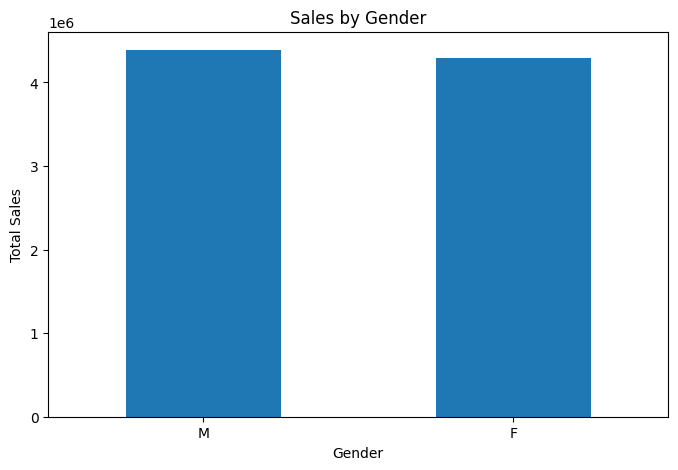

In [15]:
gender_sales.plot(kind="bar",figsize=(8,5))

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.savefig("../images/sales_by_gender.png", bbox_inches="tight")
plt.show()

## Age Group-wise Sales Analysis

This analysis compares customer count and total sales across different age groups.


In [16]:
df["Age_Group"].value_counts()

Age_Group
26-35    140
36-45    113
46-55    109
18-25     74
56-60     64
Name: count, dtype: int64

In [17]:
age_group_sales = (
    df.groupby("Age_Group")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

age_group_sales

Age_Group
26-35    2699518.230
46-55    2116806.560
36-45    1742060.135
18-25    1151000.075
56-60     970589.170
Name: Amount, dtype: float64

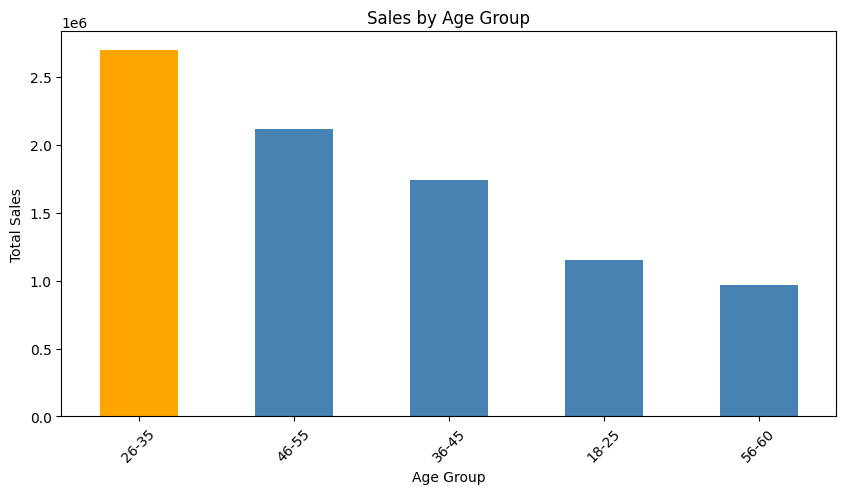

In [18]:
colors = ["steelblue"] * len(age_group_sales)

colors[age_group_sales.values.argmax()] ="orange"

age_group_sales.plot(kind="bar",figsize=(10,5),color=colors)

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.savefig("../images/age_group_sales.png",bbox_inches="tight")
plt.show()

### Business Insight

- The 26-35 age group generated the highest total sales of approximately 2.70 million.

- The 46-55 age group generated the second-higest sales of approximately 2.12 million.

- These age groups contributed significantly to overall sales and can be analyed further for customer preferences  and purchasing behavior.

## State-wise Sale Analysis

This analysis compares total sales generated across different states.

In [19]:
state_sales = (
    df.groupby("State")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

state_sales

State
Bihar             1284598.955
Tamil Nadu        1269542.380
Gujarat           1211709.080
Karnataka          964109.620
Maharashtra        834388.340
Rajasthan          829822.715
Delhi              702855.560
West Bengal        652447.170
Uttar Pradesh      501707.210
Madhya Pradesh     428793.140
Name: Amount, dtype: float64

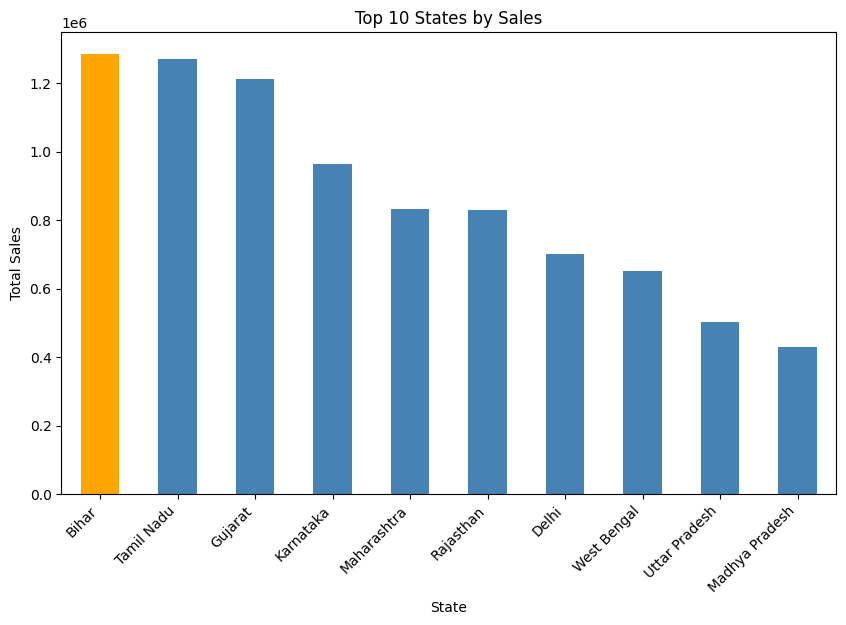

In [20]:
top_states = state_sales.head(10)

colors =["steelblue"] * len(top_states)
colors[top_states.values.argmax()] = "orange"

top_states.plot(
    kind="bar",
    figsize=(10,6),
    color=colors
)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45,ha="right")

plt.savefig("../images/top_states.png",bbox_inches="tight")
plt.show()


### Business Insight

• Bihar generated the highest total sales of approximately 1.28 million.

• Tamil Nadu and Gujarat followed with approximately 1.27 million and 1.21 million in sales, respectively.

• These states contributed significantly to overall sales and can be analyzed further to understand regional customer preferences and purchasing behavior.

## Occupation-wise Sale Analysis

This analysis compares total sales generated by customers from differents occupations.

In [21]:
df["Occupation"].value_counts()

Occupation
Teacher        58
IT             54
Finance        53
Healthcare     53
Homemaker      50
Marketing      49
Government     49
Engineering    46
Student        45
Business       43
Name: count, dtype: int64

In [22]:
occupation_sales = (
    df.groupby("Occupation")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

occupation_sales

Occupation
Healthcare     1187482.690
Homemaker      1044523.960
Finance         988520.245
Government      986213.150
Teacher         937394.960
Engineering     864609.950
Marketing       850642.370
Business        753187.650
IT              600581.750
Student         466817.445
Name: Amount, dtype: float64

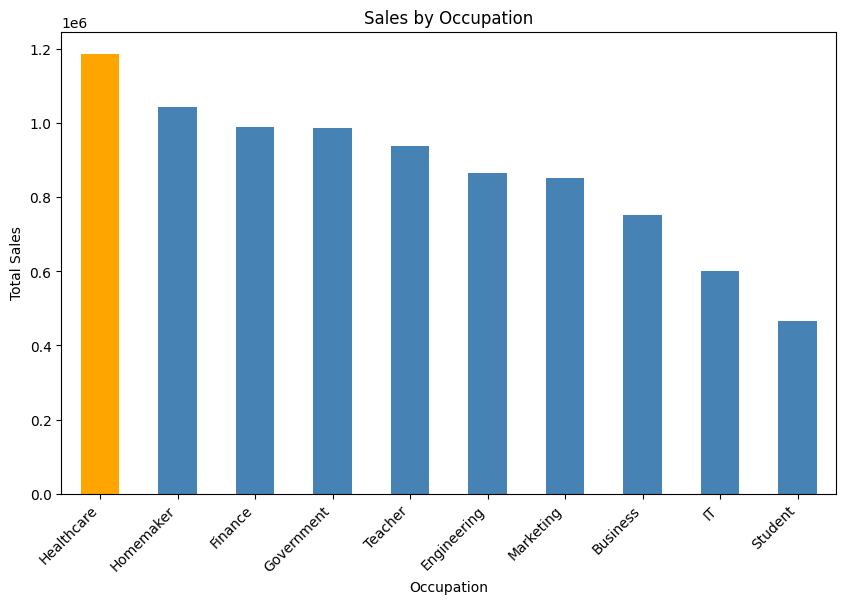

In [23]:
top_occupations = occupation_sales

colors =["steelblue"] * len(top_occupations)
colors[top_occupations.values.argmax()] = "orange"

top_occupations.plot(
    kind="bar",
    figsize=(10,6),
    color=colors
)

plt.title("Sales by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Total Sales")
plt.xticks(rotation=45,ha="right")

plt.savefig("../images/top_occupations.png",bbox_inches="tight")
plt.show()



### Business Insight

• Healthcare professionals generated the highest total sales of approximately 1.19 million.

• Homemakers generated the second-higest sales of approximately 1.04 million.

• Students contributed the lowest total sales at approximately 0.47 million.

• The business can further analyze occupation-wise purchasing patterns to understand customer preferences.


## Product-wise Sale Analysis

This analysis compares total sales generated across different product categories.

In [24]:
category_sales = (
    df.groupby("Product")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_sales

Product
Smartwatch    1697319.18
Smartphone    1203203.53
Speaker        640235.61
Bookshelf      577012.87
Headphones     546745.76
Lamp           365578.19
Laptop         337227.74
Table          311237.94
Sofa           209761.05
Jeans          206420.84
Name: Amount, dtype: float64

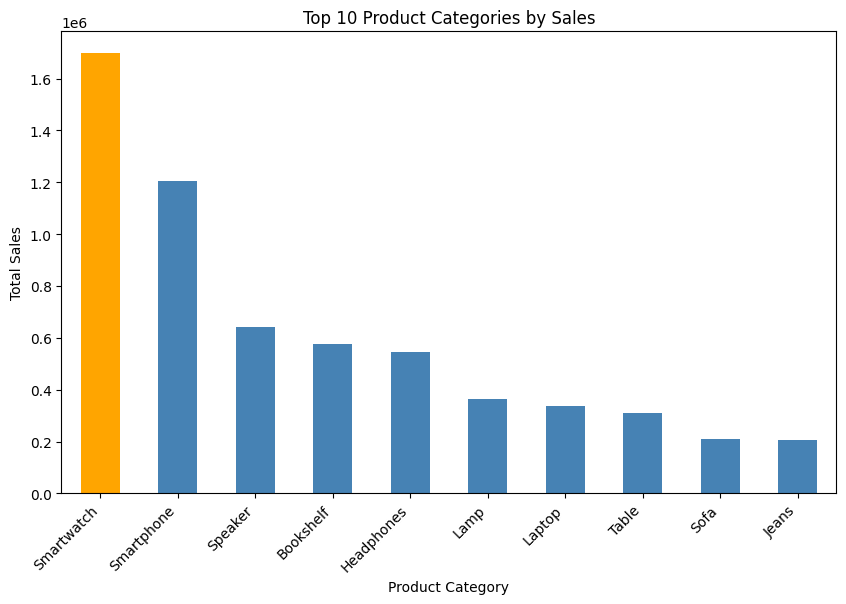

In [25]:
top_categories = category_sales
colors = ["steelblue"] * len(top_categories)
colors[top_categories.values.argmax()] = "orange"

top_categories.plot(
    kind="bar",
    figsize=(10,6),
    color=colors
)

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45,ha="right")

plt.savefig("../images/top_categories.png",bbox_inches="tight")
plt.show()

### Business Insight

• Smartwatch generated the highest total sales of approximately 1.70 million.

• Smartwatch generated the second-highest sales of approximately 1.20 million.

• Among the top 10 categories, jeans generated the lowest sales at approximately 0.21 million.

• The business can further analyze customer preferences and product demand to understand which categories contribute most to sales.

## Platform-wise Sales Analysis

This analysis compares total sales generated across different e-commerce platforms.

In [26]:
platform_sales = (
    df.groupby("Platform")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

platform_sales

Platform
Amazon           2402944.680
Flipkart         2402747.985
Offline Store    1698937.740
Meesho           1175180.580
Myntra           1000163.185
Name: Amount, dtype: float64

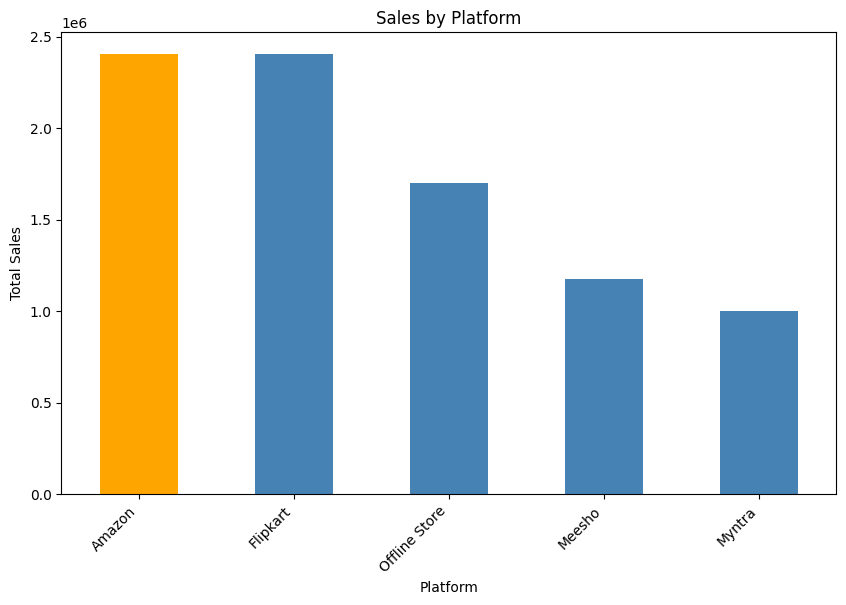

In [27]:
colors = ["steelblue"] * len(platform_sales)
colors[platform_sales.values.argmax()] = "orange"

platform_sales.plot(
    kind="bar",
    figsize=(10,6),
    color=colors
)

plt.title("Sales by Platform")
plt.xlabel("Platform")
plt.ylabel("Total Sales")
plt.xticks(rotation=45,ha="right")

plt.savefig("../images/platform_sales.png",bbox_inches="tight")
plt.show()

### Business Insight

• Amazon generated the highest total sales approximately 2.40 million.

• Flipkart generated nearly the same sales, also at approximately 2.40 million.

• Myntra generated the lowest sales among the listed platforms at approximately 1.00 million.

• The business can compare platform-wise customer behavior and sales performance to identify opportunities for growth.

## Payment Method-wise Sale Analysis

In [28]:
payment_sales = (
    df.groupby("Payment_Method")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

Payment_Method
UPI            4001723.415
Credit Card    1796280.620
Cash           1069278.210
Debit Card      996807.065
Net Banking     815884.860
Name: Amount, dtype: float64

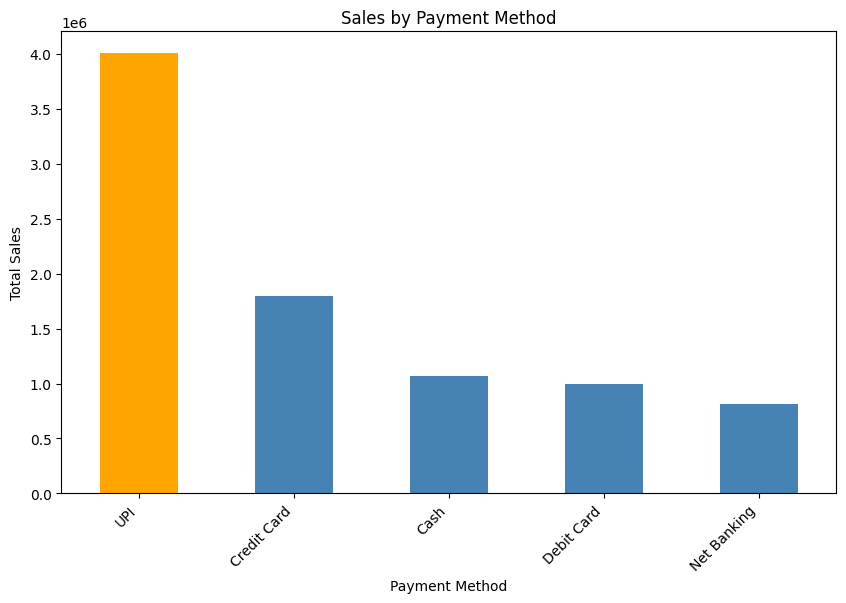

In [29]:
colors = ["steelblue"] * len(payment_sales)
colors[payment_sales.values.argmax()] = "orange"

payment_sales.plot(
    kind="bar",
    figsize=(10,6),
    color=colors
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45,ha="right")

plt.savefig("../images/payment_sales.png",bbox_inches="tight")
plt.show()

### Businss Insight

• UPI generated the highest total sales of approximately 4.00 million.

• Credit Card  generated second highest sales of approximately 1.80 million.

• The business can analyze payment preferences to improve the customer checkout experience.

### Key Business Insights

The analysis of Diwali sales data revealed the following key business insights:

• Age Group: Customer aged 26-35 generated the highest total sales of approximately 2.70 million.

• State: Bihar generated the highest total sales of approximately 1.28 million.

• Occupation: Healthcare professionals generated the highest total sales of approximately 1.19 million.

• Product Category: Smartwatch generated the highest total sales of approximately 1.70 million.

• Platform: Amazon generated the highest total sales of approximately 2.40 million.

• Payment Method: UPI generated the highest total sales of approximately 4.00 million.

### Conclusion

This Diwali Sales Analysis project used Python ,Pandas ,Numpy, Matplotlib,and Seaborn to clean,explore, and analyze sales data.

The analysis identified important patterns across customer demographics, states, occupation, product categories, platforms, and payment methods. The findings can help businesses understand customer purchasing behavior and identify areas for improving sales and customer experience.

This project demonstrates practical skills in data cleaning, explorately data analysis,data visualization, and extracting business insights from raw data.